In [1]:
# Cell 1: Segment all sessions and run quasi-stationarity validation
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "segmentation").is_dir():
            return candidate
        phase1_dir = candidate / "phase1"
        if (phase1_dir / "src" / "segmentation").is_dir():
            return phase1_dir
    raise FileNotFoundError("Cannot locate the phase1 project root")


def natural_file_key(path: Path) -> list[str | int]:
    """Sort file names in natural numeric order."""
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", path.name)
    ]


def estimate_sampling_rate(time_s: np.ndarray) -> float:
    """Estimate sampling rate from positive time intervals."""
    intervals = np.diff(time_s)
    valid = intervals[np.isfinite(intervals) & (intervals > 0)]
    if valid.size == 0:
        raise ValueError("Time axis has no positive finite interval")
    return float(1.0 / np.median(valid))


def parse_sqi(values: pd.Series) -> np.ndarray:
    """Parse a boolean SQI artifact mask."""
    if pd.api.types.is_bool_dtype(values):
        return values.to_numpy(dtype=bool)
    if pd.api.types.is_numeric_dtype(values):
        return values.to_numpy(dtype=float) != 0
    normalized = values.astype(str).str.strip().str.lower()
    mapping = {"true": True, "false": False, "1": True, "0": False}
    invalid = normalized[~normalized.isin(mapping)]
    if not invalid.empty:
        raise ValueError(f"Invalid SQI values: {invalid.unique().tolist()}")
    return normalized.map(mapping).to_numpy(dtype=bool)


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from segmentation.segmentation import (  # noqa: E402
    segment_session,
    validate_quasi_stationarity,
)

DATASET_DIR = PROJECT_ROOT / "data_processed" / "dhdata"
WINDOW_SIZES = (60, 120, 180)
SUBWINDOW_S = 10.0
THRESHOLD = 0.5
LABEL_NAMES = {0: "Awake", 1: "Drowsy"}
SIGNAL_NAMES = {"ppg_raw": "Raw", "ppg_processed": "Processed"}
SIGNAL_KEYS = tuple(SIGNAL_NAMES)
required_columns = {
    "Time (s)",
    "IR Value raw",
    "PPG processed",
    "Label",
    "SQI",
}
csv_paths = sorted(DATASET_DIR.glob("*.csv"), key=natural_file_key)
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

all_segmented = {size: [] for size in WINDOW_SIZES}
window_lookup = {}
validated_windows = []
result_rows = []
session_rows = []
for csv_path in csv_paths:
    frame = pd.read_csv(csv_path)
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing {sorted(missing)}")

    time_s = pd.to_numeric(
        frame["Time (s)"], errors="raise"
    ).to_numpy(dtype=float)
    ppg_raw = pd.to_numeric(
        frame["IR Value raw"], errors="raise"
    ).to_numpy(dtype=float)
    ppg_processed = pd.to_numeric(
        frame["PPG processed"], errors="raise"
    ).to_numpy(dtype=float)
    labels = pd.to_numeric(
        frame["Label"], errors="raise"
    ).to_numpy(dtype=int)
    sqi_mask = parse_sqi(frame["SQI"])
    fs = estimate_sampling_rate(time_s)

    segmented = segment_session(
        time_s=time_s,
        ppg_raw=ppg_raw,
        ppg_processed=ppg_processed,
        labels=labels,
        sqi_mask=sqi_mask,
        fs=fs,
        session_id=csv_path.name,
        window_sizes=WINDOW_SIZES,
    )
    session_rows.append({
        "Session": csv_path.name,
        "fs (Hz)": fs,
        "Segmented windows": sum(map(len, segmented.values())),
    })

    for window_s, windows in segmented.items():
        all_segmented[window_s].extend(windows)
        for window in windows:
            key = (csv_path.name, window_s, window["window_id"])
            window_lookup[key] = window
            for signal_key in SIGNAL_KEYS:
                score, passed = validate_quasi_stationarity(
                    window,
                    signal_key=signal_key,
                    subwindow_s=SUBWINDOW_S,
                    threshold=THRESHOLD,
                )
                evaluated = window.copy()
                evaluated["signal_key"] = signal_key
                evaluated["stationarity_score"] = score
                evaluated["stationarity_pass"] = passed
                validated_windows.append(evaluated)
                result_rows.append({
                    "Session": csv_path.name,
                    "Window (s)": window_s,
                    "Window ID": window["window_id"],
                    "Start (s)": window["start_time"],
                    "Label": LABEL_NAMES[window["label"]],
                    "Signal": SIGNAL_NAMES[signal_key],
                    "Signal key": signal_key,
                    "Score": score,
                    "Pass": passed,
                })

stationarity_results = pd.DataFrame(result_rows)
session_summary = pd.DataFrame(session_rows)
pass_fail_summary = (
    stationarity_results
    .groupby(["Window (s)", "Signal"], sort=False)["Pass"]
    .agg(N="size", Pass="sum")
    .reset_index()
)
pass_fail_summary["Fail"] = (
    pass_fail_summary["N"] - pass_fail_summary["Pass"]
)

mpl.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 120,
    "font.size": 9,
})
display(pass_fail_summary.style.hide(axis="index"))
print(
    f"Processed sessions: {len(session_summary)} | "
    f"Segmented windows: {sum(map(len, all_segmented.values()))} | "
    f"Signal evaluations: {len(stationarity_results)}"
)

Window (s),Signal,N,Pass,Fail
60,Raw,951,817,134
60,Processed,951,901,50
120,Raw,432,363,69
120,Processed,432,405,27
180,Raw,254,218,36
180,Processed,254,238,16


Processed sessions: 20 | Segmented windows: 1637 | Signal evaluations: 3274


Window (s),Signal,N,Median score,IQR,Min,Max,Pass (%)
60,Raw,951,0.210,0.230,0.007,2.298,85.91
60,Processed,951,0.151,0.175,0.006,1.363,94.74
120,Raw,432,0.251,0.225,0.027,2.282,84.03
120,Processed,432,0.189,0.182,0.021,1.726,93.75
180,Raw,254,0.270,0.201,0.049,2.382,85.83
180,Processed,254,0.203,0.175,0.038,1.192,93.70


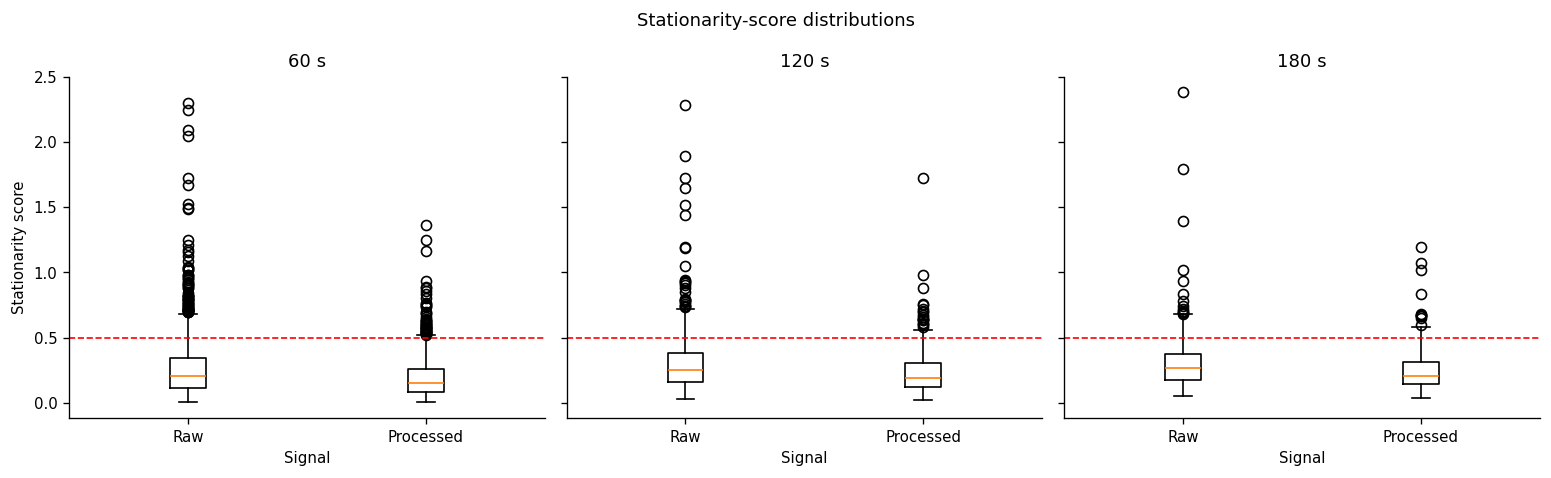

In [2]:
# Cell 2: Summarize and plot stationarity-score distributions
def score_iqr(values: pd.Series) -> float:
    """Calculate the interquartile range."""
    return float(values.quantile(0.75) - values.quantile(0.25))


distribution_rows = []
for (window_s, signal), group in stationarity_results.groupby(
    ["Window (s)", "Signal"], sort=False
):
    distribution_rows.append({
        "Window (s)": window_s,
        "Signal": signal,
        "N": len(group),
        "Median score": group["Score"].median(),
        "IQR": score_iqr(group["Score"]),
        "Min": group["Score"].min(),
        "Max": group["Score"].max(),
        "Pass (%)": 100.0 * group["Pass"].mean(),
    })

score_distribution = pd.DataFrame(distribution_rows)
display(score_distribution.style.format({
    "Median score": "{:.3f}",
    "IQR": "{:.3f}",
    "Min": "{:.3f}",
    "Max": "{:.3f}",
    "Pass (%)": "{:.2f}",
}).hide(axis="index"))

fig, axes = plt.subplots(1, len(WINDOW_SIZES), figsize=(13, 4), sharey=True)
for axis, window_s in zip(axes, WINDOW_SIZES):
    groups = [
        stationarity_results.loc[
            (stationarity_results["Window (s)"] == window_s)
            & (stationarity_results["Signal"] == signal),
            "Score",
        ].to_numpy()
        for signal in ("Raw", "Processed")
    ]
    axis.boxplot(groups, tick_labels=["Raw", "Processed"], showfliers=True)
    axis.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.0)
    axis.set_title(f"{window_s} s")
    axis.set_xlabel("Signal")
axes[0].set_ylabel("Stationarity score")
fig.suptitle("Stationarity-score distributions")
fig.tight_layout()
plt.show()

In [3]:
# Cell 3: Compare Awake and Drowsy stationarity results
state_rows = []
for keys, group in stationarity_results.groupby(
    ["Window (s)", "Signal", "Label"], sort=False
):
    window_s, signal, label = keys
    state_rows.append({
        "Window (s)": window_s,
        "Signal": signal,
        "Label": label,
        "N": len(group),
        "Median score": group["Score"].median(),
        "IQR": score_iqr(group["Score"]),
        "Pass (%)": 100.0 * group["Pass"].mean(),
    })

state_comparison = pd.DataFrame(state_rows)
display(state_comparison.style.format({
    "Median score": "{:.3f}",
    "IQR": "{:.3f}",
    "Pass (%)": "{:.2f}",
}).hide(axis="index"))

Window (s),Signal,Label,N,Median score,IQR,Pass (%)
60,Raw,Awake,623,0.186,0.217,88.28
60,Processed,Awake,623,0.140,0.164,95.67
60,Raw,Drowsy,328,0.240,0.254,81.40
60,Processed,Drowsy,328,0.170,0.205,92.99
120,Raw,Awake,284,0.222,0.217,86.27
120,Processed,Awake,284,0.174,0.160,94.72
120,Raw,Drowsy,148,0.289,0.212,79.73
120,Processed,Drowsy,148,0.213,0.215,91.89
180,Raw,Awake,168,0.260,0.213,87.50
180,Processed,Awake,168,0.193,0.173,95.83


Selection,Session,Window (s),Window ID,Label,Signal,Score,Pass
Highest score,sample_5.csv,180,13,Drowsy,Raw,2.382,False
Highest score,sample_5.csv,60,45,Drowsy,Raw,2.298,False
Highest score,sample_5.csv,120,1,Awake,Raw,2.282,False
Lowest score,sample_19.csv,60,29,Awake,Processed,0.006,True
Lowest score,sample_19.csv,60,1,Awake,Raw,0.007,True
Lowest score,sample_10.csv,60,22,Awake,Processed,0.007,True
Nearest threshold,sample_13.csv,120,23,Drowsy,Processed,0.500,True
Nearest threshold,sample_10.csv,120,16,Drowsy,Raw,0.499,True
Nearest threshold,sample_21.csv,120,10,Drowsy,Raw,0.498,True


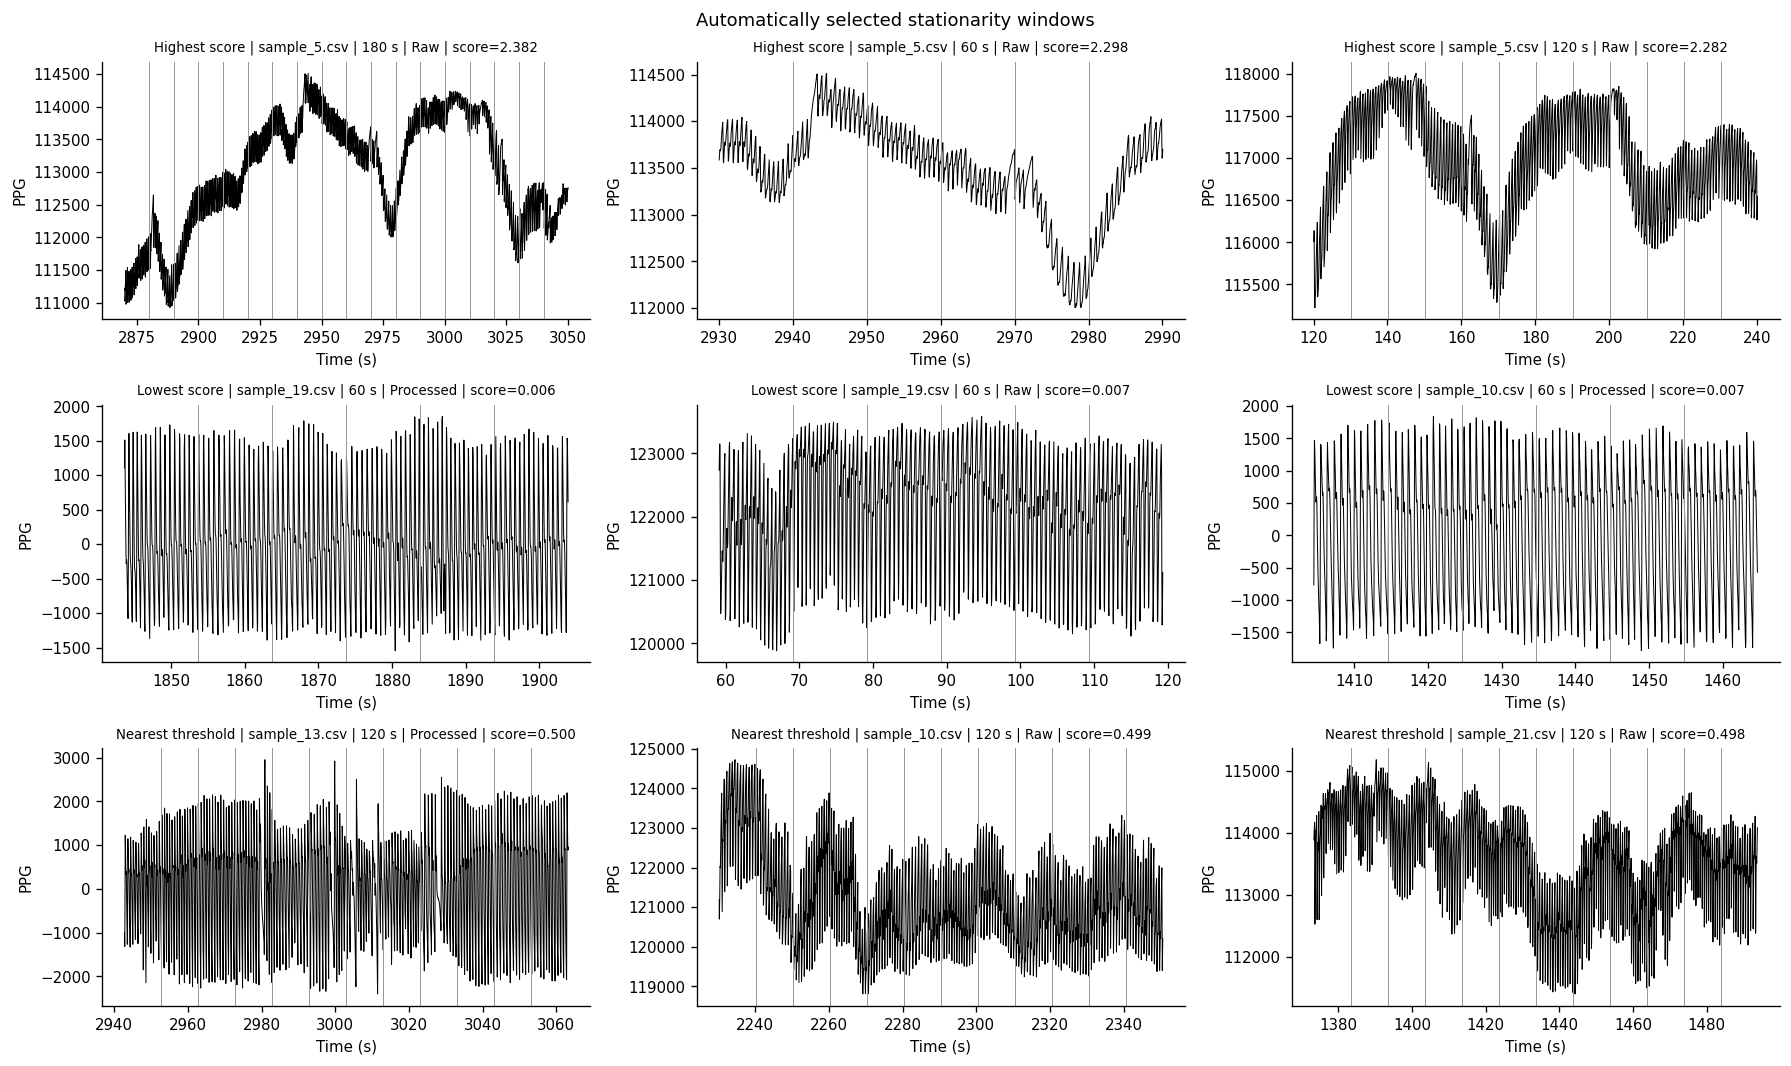

In [4]:
# Cell 4: Inspect high, low, and threshold-near scores
highest = stationarity_results.nlargest(3, "Score").copy()
highest.insert(0, "Selection", "Highest score")
lowest = stationarity_results.nsmallest(3, "Score").copy()
lowest.insert(0, "Selection", "Lowest score")
near_threshold = (
    stationarity_results
    .assign(distance=lambda frame: (frame["Score"] - THRESHOLD).abs())
    .nsmallest(3, "distance")
    .drop(columns="distance")
    .copy()
)
near_threshold.insert(0, "Selection", "Nearest threshold")
inspection_selection = pd.concat(
    [highest, lowest, near_threshold], ignore_index=True
)
display(inspection_selection[[
    "Selection",
    "Session",
    "Window (s)",
    "Window ID",
    "Label",
    "Signal",
    "Score",
    "Pass",
]].style.format({"Score": "{:.3f}"}).hide(axis="index"))

fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for axis, (_, row) in zip(axes.flat, inspection_selection.iterrows()):
    key = (row["Session"], row["Window (s)"], row["Window ID"])
    window = window_lookup[key]
    signal = window[row["Signal key"]]
    axis.plot(window["time"], signal, color="black", linewidth=0.6)
    subwindow_samples = int(round(SUBWINDOW_S * window["fs"]))
    for index in range(1, len(signal) // subwindow_samples):
        boundary = window["time"][index * subwindow_samples]
        axis.axvline(boundary, color="0.6", linewidth=0.6)
    axis.set_title(
        f"{row['Selection']} | {row['Session']} | "
        f"{row['Window (s)']} s | {row['Signal']} | "
        f"score={row['Score']:.3f}",
        fontsize=8,
    )
    axis.set_xlabel("Time (s)")
    axis.set_ylabel("PPG")
fig.suptitle("Automatically selected stationarity windows")
fig.tight_layout()
plt.show()

Selection,Session,Window (s),Signal,Min variance,Median variance,Max variance,Score reproduced
Highest score,sample_5.csv,180,Raw,17067.504,57339.248,298684.776,True
Highest score,sample_5.csv,60,Raw,31036.692,59353.295,252231.320,True
Highest score,sample_5.csv,120,Raw,51142.307,98341.132,413720.794,True
Lowest score,sample_19.csv,60,Processed,658743.045,663909.233,669371.725,True
Lowest score,sample_19.csv,60,Raw,741923.780,777545.158,795028.670,True
Lowest score,sample_10.csv,60,Processed,845170.448,917208.455,953323.281,True
Nearest threshold,sample_13.csv,120,Processed,574738.675,1335364.946,1697014.048,True
Nearest threshold,sample_10.csv,120,Raw,675552.866,765573.019,1603660.177,True
Nearest threshold,sample_21.csv,120,Raw,158158.330,286070.652,511853.341,True


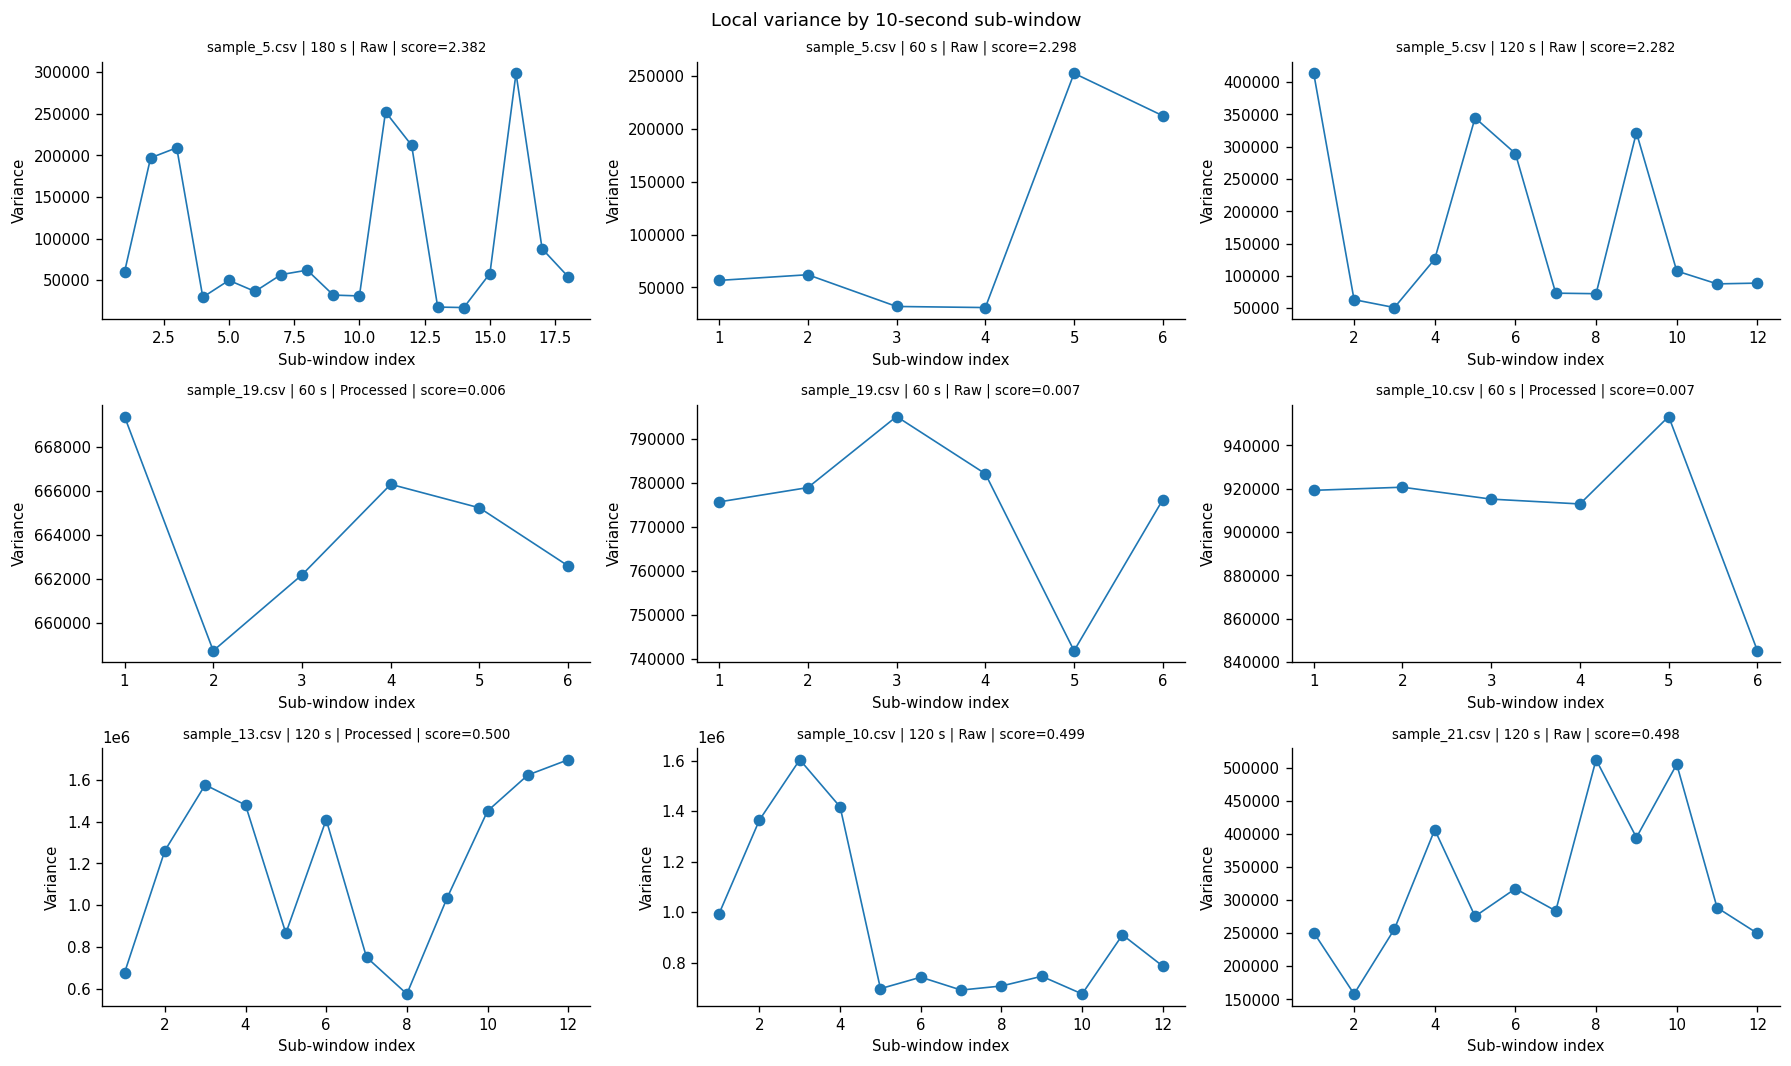

In [5]:
# Cell 5: Reproduce local variances for selected windows
def local_variances(
    window: dict, signal_key: str, subwindow_s: float
) -> np.ndarray:
    """Calculate complete-subwindow variances."""
    signal = np.asarray(window[signal_key], dtype=float)
    samples = int(round(subwindow_s * window["fs"]))
    count = len(signal) // samples
    return np.array([
        np.var(signal[index * samples:(index + 1) * samples])
        for index in range(count)
    ])


variance_rows = []
variance_summary_rows = []
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
for selection_id, (axis, (_, row)) in enumerate(
    zip(axes.flat, inspection_selection.iterrows()), start=1
):
    key = (row["Session"], row["Window (s)"], row["Window ID"])
    window = window_lookup[key]
    variances = local_variances(
        window, row["Signal key"], SUBWINDOW_S
    )
    median_variance = np.median(variances)
    reproduced_score = (
        np.quantile(variances, 0.75)
        - np.quantile(variances, 0.25)
    ) / max(median_variance, np.finfo(float).eps)
    score_matches = bool(np.isclose(reproduced_score, row["Score"]))
    variance_summary_rows.append({
        "Selection": row["Selection"],
        "Session": row["Session"],
        "Window (s)": row["Window (s)"],
        "Signal": row["Signal"],
        "Min variance": variances.min(),
        "Median variance": median_variance,
        "Max variance": variances.max(),
        "Score reproduced": score_matches,
    })
    for index, variance in enumerate(variances, start=1):
        variance_rows.append({
            "Selection ID": selection_id,
            "Sub-window": index,
            "Variance": variance,
        })
    axis.plot(
        np.arange(1, len(variances) + 1),
        variances,
        marker="o",
        linewidth=1.0,
    )
    axis.set_title(
        f"{row['Session']} | {row['Window (s)']} s | "
        f"{row['Signal']} | score={row['Score']:.3f}",
        fontsize=8,
    )
    axis.set_xlabel("Sub-window index")
    axis.set_ylabel("Variance")

variance_diagnostic = pd.DataFrame(variance_rows)
variance_summary = pd.DataFrame(variance_summary_rows)
if not variance_summary["Score reproduced"].all():
    raise AssertionError("A local-variance score was not reproduced")
display(variance_summary.style.format({
    "Min variance": "{:.3f}",
    "Median variance": "{:.3f}",
    "Max variance": "{:.3f}",
}).hide(axis="index"))
fig.suptitle("Local variance by 10-second sub-window")
fig.tight_layout()
plt.show()

In [6]:
# Cell 6: Run synthetic variance-stability tests
rng = np.random.default_rng(42)
synthetic_fs = 50.0
synthetic_samples = int(60 * synthetic_fs)
stable_signal = rng.normal(0.0, 1.0, synthetic_samples)
increasing_signal = (
    rng.normal(0.0, 1.0, synthetic_samples)
    * np.linspace(0.5, 3.5, synthetic_samples)
)
burst_signal = rng.normal(0.0, 1.0, synthetic_samples)
burst_signal[int(20 * synthetic_fs):int(40 * synthetic_fs)] *= 5.0
synthetic_signals = {
    "Stable variance": stable_signal,
    "Increasing variance": increasing_signal,
    "High-variance segment": burst_signal,
}

synthetic_rows = []
for name, signal in synthetic_signals.items():
    synthetic_window = {"ppg_processed": signal, "fs": synthetic_fs}
    score, passed = validate_quasi_stationarity(
        synthetic_window,
        signal_key="ppg_processed",
        subwindow_s=SUBWINDOW_S,
        threshold=THRESHOLD,
    )
    synthetic_rows.append({
        "Signal": name,
        "Score": score,
        "Pass": passed,
    })

synthetic_summary = pd.DataFrame(synthetic_rows)
stable_score = synthetic_summary.loc[
    synthetic_summary["Signal"] == "Stable variance", "Score"
].iat[0]
other_scores = synthetic_summary.loc[
    synthetic_summary["Signal"] != "Stable variance", "Score"
]
synthetic_order_passed = bool((stable_score < other_scores).all())
if not synthetic_order_passed:
    raise AssertionError("Synthetic score ordering is incorrect")
display(
    synthetic_summary.style.format({"Score": "{:.3f}"})
    .hide(axis="index")
)
print(f"Synthetic score ordering passed: {synthetic_order_passed}")

Signal,Score,Pass
Stable variance,0.028,True
Increasing variance,1.201,False
High-variance segment,15.233,False


Synthetic score ordering passed: True


In [7]:
# Cell 7: Evaluate sub-window and threshold sensitivity
sensitivity_rows = []
for subwindow_s in (5.0, 10.0, 15.0):
    for threshold in (0.3, 0.5, 0.7):
        decisions = []
        awake_decisions = []
        drowsy_decisions = []
        for windows in all_segmented.values():
            for window in windows:
                for signal_key in SIGNAL_KEYS:
                    _, passed = validate_quasi_stationarity(
                        window,
                        signal_key=signal_key,
                        subwindow_s=subwindow_s,
                        threshold=threshold,
                    )
                    decisions.append(passed)
                    target = (
                        awake_decisions
                        if window["label"] == 0
                        else drowsy_decisions
                    )
                    target.append(passed)
        sensitivity_rows.append({
            "Sub-window (s)": subwindow_s,
            "Threshold": threshold,
            "Pass (%)": 100.0 * np.mean(decisions),
            "Awake pass (%)": 100.0 * np.mean(awake_decisions),
            "Drowsy pass (%)": 100.0 * np.mean(drowsy_decisions),
        })

parameter_sensitivity = pd.DataFrame(sensitivity_rows)
display(parameter_sensitivity.style.format({
    "Sub-window (s)": "{:.0f}",
    "Threshold": "{:.1f}",
    "Pass (%)": "{:.2f}",
    "Awake pass (%)": "{:.2f}",
    "Drowsy pass (%)": "{:.2f}",
}).hide(axis="index"))
print("Sensitivity percentages combine raw and processed evaluations.")

Sub-window (s),Threshold,Pass (%),Awake pass (%),Drowsy pass (%)
5,0.3,66.13,68.56,61.48
5,0.5,89.55,91.58,85.68
5,0.7,96.30,97.21,94.57
10,0.3,71.29,74.23,65.66
10,0.5,89.86,91.53,86.65
10,0.7,96.09,96.93,94.48
15,0.3,73.37,75.72,68.86
15,0.5,90.56,92.19,87.46
15,0.7,95.66,96.88,93.33


Sensitivity percentages combine raw and processed evaluations.


Window (s),N,Score correlation,Different decisions,Different (%)
60,951,0.512,114,11.99
120,432,0.490,60,13.89
180,254,0.482,34,13.39
Overall,1637,0.505,208,12.71


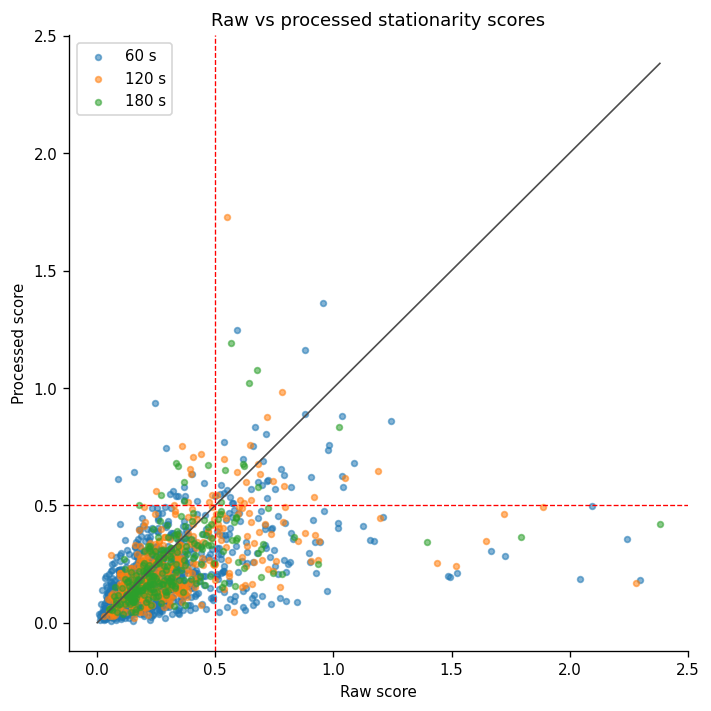

In [8]:
# Cell 8: Compare raw and processed scores for matched windows
match_keys = ["Session", "Window (s)", "Window ID", "Label"]
raw_results = stationarity_results.loc[
    stationarity_results["Signal"] == "Raw",
    match_keys + ["Score", "Pass"],
]
processed_results = stationarity_results.loc[
    stationarity_results["Signal"] == "Processed",
    match_keys + ["Score", "Pass"],
]
matched_scores = raw_results.merge(
    processed_results, on=match_keys, suffixes=(" raw", " processed")
)

consistency_rows = []
for window_s in (*WINDOW_SIZES, "Overall"):
    group = (
        matched_scores
        if window_s == "Overall"
        else matched_scores[matched_scores["Window (s)"] == window_s]
    )
    correlation = np.corrcoef(
        group["Score raw"], group["Score processed"]
    )[0, 1]
    different = group["Pass raw"] != group["Pass processed"]
    consistency_rows.append({
        "Window (s)": window_s,
        "N": len(group),
        "Score correlation": correlation,
        "Different decisions": int(different.sum()),
        "Different (%)": 100.0 * different.mean(),
    })

raw_processed_consistency = pd.DataFrame(consistency_rows)
display(raw_processed_consistency.style.format({
    "Score correlation": "{:.3f}",
    "Different (%)": "{:.2f}",
}).hide(axis="index"))

fig, axis = plt.subplots(figsize=(6, 6))
for window_s in WINDOW_SIZES:
    group = matched_scores[matched_scores["Window (s)"] == window_s]
    axis.scatter(
        group["Score raw"],
        group["Score processed"],
        s=12,
        alpha=0.55,
        label=f"{window_s} s",
    )
score_limit = max(
    matched_scores["Score raw"].max(),
    matched_scores["Score processed"].max(),
)
axis.plot([0, score_limit], [0, score_limit], color="0.3", linewidth=1.0)
axis.axvline(THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axis.axhline(THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axis.set(
    title="Raw vs processed stationarity scores",
    xlabel="Raw score",
    ylabel="Processed score",
)
axis.legend()
fig.tight_layout()
plt.show()

In [9]:
# Cell 9: Summarize final retention after SQI and stationarity
processed_stationarity = stationarity_results[
    stationarity_results["Signal"] == "Processed"
]
retention_rows = []
state_retention_rows = []
for window_s in WINDOW_SIZES:
    group = processed_stationarity[
        processed_stationarity["Window (s)"] == window_s
    ]
    segmented_count = len(all_segmented[window_s])
    passed_count = int(group["Pass"].sum())
    retention_rows.append({
        "Window (s)": window_s,
        "Segmented": segmented_count,
        "Stationarity pass": passed_count,
        "Final retained": passed_count,
        "Retention (%)": 100.0 * passed_count / segmented_count,
    })
    for label in ("Awake", "Drowsy"):
        state_group = group[group["Label"] == label]
        state_passed = int(state_group["Pass"].sum())
        state_retention_rows.append({
            "Window (s)": window_s,
            "Label": label,
            "Segmented": len(state_group),
            "Final retained": state_passed,
            "Retention (%)": (
                100.0 * state_passed / len(state_group)
                if len(state_group)
                else np.nan
            ),
        })

final_retention = pd.DataFrame(retention_rows)
state_retention = pd.DataFrame(state_retention_rows)
display(final_retention.style.format({
    "Retention (%)": "{:.2f}",
}).hide(axis="index"))
display(state_retention.style.format({
    "Retention (%)": "{:.2f}",
}).hide(axis="index"))
print(
    f"Final processed-signal windows: "
    f"{int(final_retention['Final retained'].sum())} / "
    f"{int(final_retention['Segmented'].sum())}"
)

Window (s),Segmented,Stationarity pass,Final retained,Retention (%)
60,951,901,901,94.74
120,432,405,405,93.75
180,254,238,238,93.70


Window (s),Label,Segmented,Final retained,Retention (%)
60,Awake,623,596,95.67
60,Drowsy,328,305,92.99
120,Awake,284,269,94.72
120,Drowsy,148,136,91.89
180,Awake,168,161,95.83
180,Drowsy,86,77,89.53


Final processed-signal windows: 1544 / 1637


# Báo cáo kết quả kiểm thử quasi-stationarity

## 1. Phạm vi và cấu hình

| Nội dung | Kết quả |
| --- | ---: |
| Processed session | 20 |
| Segmented window 60 s | 951 |
| Segmented window 120 s | 432 |
| Segmented window 180 s | 254 |
| Tổng segmented window | 1.637 |
| Tổng lượt đánh giá raw và processed | 3.274 |
| Sub-window chính | 10 s |
| Threshold chính | 0,5 |

Mỗi representation-specific window record chứa `stationarity_score` và `stationarity_pass`.

## 2. Số window pass/fail

| Window (s) | Signal | N | Pass | Fail |
| ---: | --- | ---: | ---: | ---: |
| 60 | Raw | 951 | 817 | 134 |
| 60 | Processed | 951 | 901 | 50 |
| 120 | Raw | 432 | 363 | 69 |
| 120 | Processed | 432 | 405 | 27 |
| 180 | Raw | 254 | 218 | 36 |
| 180 | Processed | 254 | 238 | 16 |

## 3. Phân phối stationarity score

| Window (s) | Signal | N | Median | IQR | Min | Max | Pass (%) |
| ---: | --- | ---: | ---: | ---: | ---: | ---: | ---: |
| 60 | Raw | 951 | 0,210 | 0,230 | 0,007 | 2,298 | 85,91 |
| 60 | Processed | 951 | 0,151 | 0,175 | 0,006 | 1,363 | 94,74 |
| 120 | Raw | 432 | 0,251 | 0,225 | 0,027 | 2,282 | 84,03 |
| 120 | Processed | 432 | 0,189 | 0,182 | 0,021 | 1,726 | 93,75 |
| 180 | Raw | 254 | 0,270 | 0,201 | 0,049 | 2,382 | 85,83 |
| 180 | Processed | 254 | 0,203 | 0,175 | 0,038 | 1,192 | 93,70 |

Notebook đã tạo boxplot score cho Raw và Processed ở từng window size, kèm đường threshold 0,5.

## 4. Kết quả theo Awake và Drowsy

| Window (s) | Signal | Label | N | Median | IQR | Pass (%) |
| ---: | --- | --- | ---: | ---: | ---: | ---: |
| 60 | Raw | Awake | 623 | 0,186 | 0,217 | 88,28 |
| 60 | Processed | Awake | 623 | 0,140 | 0,164 | 95,67 |
| 60 | Raw | Drowsy | 328 | 0,240 | 0,254 | 81,40 |
| 60 | Processed | Drowsy | 328 | 0,170 | 0,205 | 92,99 |
| 120 | Raw | Awake | 284 | 0,222 | 0,217 | 86,27 |
| 120 | Processed | Awake | 284 | 0,174 | 0,160 | 94,72 |
| 120 | Raw | Drowsy | 148 | 0,289 | 0,212 | 79,73 |
| 120 | Processed | Drowsy | 148 | 0,213 | 0,215 | 91,89 |
| 180 | Raw | Awake | 168 | 0,260 | 0,213 | 87,50 |
| 180 | Processed | Awake | 168 | 0,193 | 0,173 | 95,83 |
| 180 | Raw | Drowsy | 86 | 0,279 | 0,167 | 82,56 |
| 180 | Processed | Drowsy | 86 | 0,223 | 0,194 | 89,53 |

## 5. Window được chọn để visual inspection

| Selection | Session | Window (s) | ID | Label | Signal | Score | Pass |
| --- | --- | ---: | ---: | --- | --- | ---: | --- |
| Highest | `sample_5.csv` | 180 | 13 | Drowsy | Raw | 2,382 | False |
| Highest | `sample_5.csv` | 60 | 45 | Drowsy | Raw | 2,298 | False |
| Highest | `sample_5.csv` | 120 | 1 | Awake | Raw | 2,282 | False |
| Lowest | `sample_19.csv` | 60 | 29 | Awake | Processed | 0,006 | True |
| Lowest | `sample_19.csv` | 60 | 1 | Awake | Raw | 0,007 | True |
| Lowest | `sample_10.csv` | 60 | 22 | Awake | Processed | 0,007 | True |
| Nearest threshold | `sample_13.csv` | 120 | 23 | Drowsy | Processed | 0,500 | True |
| Nearest threshold | `sample_10.csv` | 120 | 16 | Drowsy | Raw | 0,499 | True |
| Nearest threshold | `sample_21.csv` | 120 | 10 | Drowsy | Raw | 0,498 | True |

Waveform của chín window trên đã được plot, với các boundary 10 giây được đánh dấu.

## 6. Local variance diagnostic

| Selection | Session | Window (s) | Signal | Min variance | Median variance | Max variance | Score reproduced |
| --- | --- | ---: | --- | ---: | ---: | ---: | --- |
| Highest | `sample_5.csv` | 180 | Raw | 17.067,504 | 57.339,248 | 298.684,776 | True |
| Highest | `sample_5.csv` | 60 | Raw | 31.036,692 | 59.353,295 | 252.231,320 | True |
| Highest | `sample_5.csv` | 120 | Raw | 51.142,307 | 98.341,132 | 413.720,794 | True |
| Lowest | `sample_19.csv` | 60 | Processed | 658.743,045 | 663.909,233 | 669.371,725 | True |
| Lowest | `sample_19.csv` | 60 | Raw | 741.923,780 | 777.545,158 | 795.028,670 | True |
| Lowest | `sample_10.csv` | 60 | Processed | 845.170,448 | 917.208,455 | 953.323,281 | True |
| Near threshold | `sample_13.csv` | 120 | Processed | 574.738,675 | 1.335.364,946 | 1.697.014,048 | True |
| Near threshold | `sample_10.csv` | 120 | Raw | 675.552,866 | 765.573,019 | 1.603.660,177 | True |
| Near threshold | `sample_21.csv` | 120 | Raw | 158.158,330 | 286.070,652 | 511.853,341 | True |

Variance của từng sub-window đã được lưu trong `variance_diagnostic` và plot theo sub-window index. Score của cả chín window đều được tái tạo từ local variance.

## 7. Synthetic sanity test

| Synthetic signal | Score | Pass |
| --- | ---: | --- |
| Stable variance | 0,028 | True |
| Increasing variance | 1,201 | False |
| High-variance segment | 15,233 | False |

Kiểm tra thứ tự score ghi nhận stable signal có score thấp hơn hai non-stationary signal.

## 8. Parameter sensitivity

Các tỷ lệ dưới đây gộp cả Raw và Processed ở ba analysis-window size.

| Sub-window (s) | Threshold | Pass (%) | Awake pass (%) | Drowsy pass (%) |
| ---: | ---: | ---: | ---: | ---: |
| 5 | 0,3 | 66,13 | 68,56 | 61,48 |
| 5 | 0,5 | 89,55 | 91,58 | 85,68 |
| 5 | 0,7 | 96,30 | 97,21 | 94,57 |
| 10 | 0,3 | 71,29 | 74,23 | 65,66 |
| 10 | 0,5 | 89,86 | 91,53 | 86,65 |
| 10 | 0,7 | 96,09 | 96,93 | 94,48 |
| 15 | 0,3 | 73,37 | 75,72 | 68,86 |
| 15 | 0,5 | 90,56 | 92,19 | 87,46 |
| 15 | 0,7 | 95,66 | 96,88 | 93,33 |

## 9. Raw và Processed consistency

| Window (s) | N | Score correlation | Different decisions | Different (%) |
| ---: | ---: | ---: | ---: | ---: |
| 60 | 951 | 0,512 | 114 | 11,99 |
| 120 | 432 | 0,490 | 60 | 13,89 |
| 180 | 254 | 0,482 | 34 | 13,39 |
| Overall | 1.637 | 0,505 | 208 | 12,71 |

Notebook đã tạo scatter Raw score theo Processed score, kèm đường đồng nhất và hai đường threshold 0,5.

## 10. Final retention với Processed PPG

| Window (s) | Segmented | Stationarity pass | Final retained | Retention (%) |
| ---: | ---: | ---: | ---: | ---: |
| 60 | 951 | 901 | 901 | 94,74 |
| 120 | 432 | 405 | 405 | 93,75 |
| 180 | 254 | 238 | 238 | 93,70 |
| **Total** | **1.637** | **1.544** | **1.544** | **94,32** |

| Window (s) | Label | Segmented | Final retained | Retention (%) |
| ---: | --- | ---: | ---: | ---: |
| 60 | Awake | 623 | 596 | 95,67 |
| 60 | Drowsy | 328 | 305 | 92,99 |
| 120 | Awake | 284 | 269 | 94,72 |
| 120 | Drowsy | 148 | 136 | 91,89 |
| 180 | Awake | 168 | 161 | 95,83 |
| 180 | Drowsy | 86 | 77 | 89,53 |

Báo cáo này chỉ tổng hợp các output đã thu được trong chín cell thực nghiệm.


# Quasi-Stationarity Validation — Kết luận

Cấu hình được chọn:


Sub-window = 10 s
Score = IQR(local variance) / median(local variance)
Threshold = 0.5
Pass nếu score <= 0.5

Lý do lựa chọn
10 s giữ được tính cục bộ nhưng vẫn đủ mẫu để ước lượng variance ổn định.
Sensitivity analysis với 5/10/15 s cho kết quả gần tương đương, cho thấy lựa chọn 10 s không quá nhạy.
threshold = 0.5 tạo mức kiểm tra trung gian:
0.3 quá nghiêm;
0.7 quá lỏng;
0.5 giữ được khoảng 90% window.
Synthetic test và visual inspection xác nhận score thấp tương ứng variance ổn định, score cao tương ứng biến đổi variance rõ ràng.
Kết luận

10 s / 0.5 được freeze như tiêu chí quasi-stationarity chính.

# CONCLUSION

Label được dùng để ngăn analysis window đi qua transition Awake–Drowsy, từ đó giảm khả năng variance thay đổi chỉ vì chuyển trạng thái sinh lý đã biết. Sau đó, SQI và quasi-stationarity được đánh giá độc lập với label để loại artifact và các window có biến thiên nội tại quá lớn trước khi đưa vào NTSA.

In [10]:
# Cell 10: Export segmented windows by session
SEGMENTATED_DIR = PROJECT_ROOT / "segmentated_data" / "dhdata"
SEGMENTATED_DIR.mkdir(parents=True, exist_ok=True)

score_lookup = {
    (
        row["Session"],
        int(row["Window (s)"]),
        int(row["Window ID"]),
        row["Signal key"],
    ): (float(row["Score"]), bool(row["Pass"]))
    for _, row in stationarity_results.iterrows()
}
session_fs = session_summary.set_index("Session")["fs (Hz)"].to_dict()

index_rows = []
storage_rows = []
written_paths = []
for session_name in session_summary["Session"]:
    fs = float(session_fs[session_name])
    payload = {"fs": np.array(fs, dtype=float)}
    size_counts = {}

    for window_s in WINDOW_SIZES:
        windows = sorted(
            [
                window for window in all_segmented[window_s]
                if window["session"] == session_name
            ],
            key=lambda window: window["window_id"],
        )
        n_samples = int(round(window_s * fs))
        if any(len(window["time"]) != n_samples for window in windows):
            raise AssertionError(
                f"Unexpected sample count in {session_name}, {window_s} s"
            )

        raw = (
            np.stack([window["ppg_raw"] for window in windows])
            if windows
            else np.empty((0, n_samples), dtype=float)
        )
        processed = (
            np.stack([window["ppg_processed"] for window in windows])
            if windows
            else np.empty((0, n_samples), dtype=float)
        )
        window_ids = np.array(
            [window["window_id"] for window in windows], dtype=int
        )
        labels = np.array([window["label"] for window in windows], dtype=int)
        start_times = np.array(
            [window["start_time"] for window in windows], dtype=float
        )
        end_times = np.array(
            [window["end_time"] for window in windows], dtype=float
        )
        raw_results = [
            score_lookup[(session_name, window_s, window_id, "ppg_raw")]
            for window_id in window_ids
        ]
        processed_results = [
            score_lookup[(
                session_name, window_s, window_id, "ppg_processed"
            )]
            for window_id in window_ids
        ]
        raw_scores = np.array([item[0] for item in raw_results], dtype=float)
        raw_passes = np.array([item[1] for item in raw_results], dtype=bool)
        processed_scores = np.array(
            [item[0] for item in processed_results], dtype=float
        )
        processed_passes = np.array(
            [item[1] for item in processed_results], dtype=bool
        )

        prefix = str(window_s)
        payload.update({
            f"{prefix}/raw": raw,
            f"{prefix}/processed": processed,
            f"{prefix}/window_id": window_ids,
            f"{prefix}/label": labels,
            f"{prefix}/start_time": start_times,
            f"{prefix}/end_time": end_times,
            f"{prefix}/stationarity_score_raw": raw_scores,
            f"{prefix}/stationarity_pass_raw": raw_passes,
            f"{prefix}/stationarity_score_processed": processed_scores,
            f"{prefix}/stationarity_pass_processed": processed_passes,
        })

        for row_index, window in enumerate(windows):
            index_rows.append({
                "session": session_name,
                "npz_file": f"{Path(session_name).stem}.npz",
                "row_index": row_index,
                "window_id": window["window_id"],
                "window_size_s": window_s,
                "label": window["label"],
                "start_time": window["start_time"],
                "end_time": window["end_time"],
                "fs": fs,
                "n_samples": n_samples,
                "stationarity_score_raw": raw_scores[row_index],
                "stationarity_pass_raw": raw_passes[row_index],
                "stationarity_score_processed": (
                    processed_scores[row_index]
                ),
                "stationarity_pass_processed": (
                    processed_passes[row_index]
                ),
            })
        size_counts[window_s] = len(windows)

    output_path = SEGMENTATED_DIR / f"{Path(session_name).stem}.npz"
    temporary_path = output_path.with_suffix(".tmp.npz")
    np.savez_compressed(temporary_path, **payload)
    temporary_path.replace(output_path)
    written_paths.append(output_path)
    storage_rows.append({
        "Session": session_name,
        "File": output_path.name,
        "60 s": size_counts[60],
        "120 s": size_counts[120],
        "180 s": size_counts[180],
        "Total": sum(size_counts.values()),
    })

segments_index = pd.DataFrame(index_rows).sort_values(
    ["session", "window_size_s", "window_id"]
).reset_index(drop=True)
index_path = SEGMENTATED_DIR / "segments_index.csv"
temporary_index_path = index_path.with_suffix(".tmp")
segments_index.to_csv(temporary_index_path, index=False)
temporary_index_path.replace(index_path)
storage_summary = pd.DataFrame(storage_rows)

expected_keys = {"fs"}
for window_s in WINDOW_SIZES:
    expected_keys.update({
        f"{window_s}/raw",
        f"{window_s}/processed",
        f"{window_s}/window_id",
        f"{window_s}/label",
        f"{window_s}/start_time",
        f"{window_s}/end_time",
        f"{window_s}/stationarity_score_raw",
        f"{window_s}/stationarity_pass_raw",
        f"{window_s}/stationarity_score_processed",
        f"{window_s}/stationarity_pass_processed",
    })

schema_valid = True
alignment_valid = True
metadata_valid = True
index_values_valid = True
for output_path in written_paths:
    session_name = f"{output_path.stem}.csv"
    session_index = segments_index[segments_index["session"] == session_name]
    with np.load(output_path, allow_pickle=False) as archive:
        schema_valid &= set(archive.files) == expected_keys
        for window_s in WINDOW_SIZES:
            prefix = str(window_s)
            raw = archive[f"{prefix}/raw"]
            processed = archive[f"{prefix}/processed"]
            rows = session_index[
                session_index["window_size_s"] == window_s
            ].sort_values("row_index")
            count = len(rows)
            alignment_valid &= raw.shape == processed.shape
            alignment_valid &= raw.shape[0] == count
            metadata_valid &= all(
                archive[f"{prefix}/{name}"].shape == (count,)
                for name in (
                    "window_id",
                    "label",
                    "start_time",
                    "end_time",
                    "stationarity_score_raw",
                    "stationarity_pass_raw",
                    "stationarity_score_processed",
                    "stationarity_pass_processed",
                )
            )
            index_values_valid &= np.array_equal(
                archive[f"{prefix}/window_id"], rows["window_id"]
            )
            index_values_valid &= np.allclose(
                archive[f"{prefix}/start_time"], rows["start_time"]
            )
            index_values_valid &= np.allclose(
                archive[f"{prefix}/end_time"], rows["end_time"]
            )

validation_rows = [
    {
        "Check": "One NPZ file per session",
        "Pass": len(written_paths) == len(session_summary),
    },
    {
        "Check": "One index row per segmented window",
        "Pass": len(segments_index) == sum(map(len, all_segmented.values())),
    },
    {"Check": "Complete NPZ key schema", "Pass": schema_valid},
    {"Check": "Raw/processed shape alignment", "Pass": alignment_valid},
    {"Check": "Metadata length alignment", "Pass": metadata_valid},
    {
        "Check": "Index identifiers and intervals match NPZ",
        "Pass": index_values_valid,
    },
    {
        "Check": "Unique session/window identifiers",
        "Pass": not segments_index.duplicated(
            ["session", "window_size_s", "window_id"]
        ).any(),
    },
]
storage_validation = pd.DataFrame(validation_rows)
if not storage_validation["Pass"].all():
    raise AssertionError("Segmented dataset storage validation failed")

display(storage_summary.style.hide(axis="index"))
display(storage_validation.style.hide(axis="index"))
print(f"Saved {len(written_paths)} session files to {SEGMENTATED_DIR}")
print(f"Index rows: {len(segments_index):,} | Index: {index_path.name}")

Session,File,60 s,120 s,180 s,Total
sample_1.csv,sample_1.npz,34,14,7,55
sample_4.csv,sample_4.npz,46,20,13,79
sample_5.csv,sample_5.npz,54,25,14,93
sample_6.csv,sample_6.npz,50,22,14,86
sample_7.csv,sample_7.npz,49,24,14,87
sample_8.csv,sample_8.npz,48,23,13,84
sample_9.csv,sample_9.npz,71,32,19,122
sample_10.csv,sample_10.npz,36,16,9,61
sample_11.csv,sample_11.npz,38,17,11,66
sample_12.csv,sample_12.npz,56,25,16,97


Check,Pass
One NPZ file per session,True
One index row per segmented window,True
Complete NPZ key schema,True
Raw/processed shape alignment,True
Metadata length alignment,True
Index identifiers and intervals match NPZ,True
Unique session/window identifiers,True


Saved 20 session files to C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\segmentated_data\dhdata
Index rows: 1,637 | Index: segments_index.csv
